In [1]:
import numpy as np
import sympy as smp
import matplotlib.pyplot as plt

# Textbook Example

$$\begin{align}\dot x =& \sigma(y-x)\\
\dot y =& \rho x + x - y - xz \\
\dot z =& -\beta z + xy\end{align}$$

In [2]:
x, y, z, sig, rho, bet = smp.symbols(r'x y z \sigma \rho \beta')

dx = sig*(y-x)
dx

\sigma*(-x + y)

In [3]:
dy = rho*x+x-y-x*z
dy

\rho*x - x*z + x - y

In [4]:
dz = -bet*z + x*y
dz

-\beta*z + x*y

In [21]:
Jac = smp.Matrix([[smp.diff(dx,x),smp.diff(dx,y),smp.diff(dx,z)],
                  [smp.diff(dy,x),smp.diff(dy,y),smp.diff(dy,z)],
                  [smp.diff(dz,x),smp.diff(dz,y),smp.diff(dz,z)]])
J0 = Jac.subs([[x,0],[y,0],[z,0],[rho,0]])

In [22]:
J0.eigenvects()

[(0,
  1,
  [Matrix([
   [1],
   [1],
   [0]])]),
 (-\beta,
  1,
  [Matrix([
   [0],
   [0],
   [1]])]),
 (-\sigma - 1,
  1,
  [Matrix([
   [-\sigma],
   [      1],
   [      0]])])]

In [24]:
e1 = J0.eigenvects()[0][0]
v1 = J0.eigenvects()[0][-1][0]

e2 = J0.eigenvects()[1][0]
v2 = J0.eigenvects()[1][-1][0]

e3 = J0.eigenvects()[2][0]
v3 = J0.eigenvects()[2][-1][0]

In [25]:
e1

0

In [26]:
e2

-\beta

In [27]:
e3

-\sigma - 1

### Change of Base

In [30]:
P = smp.Matrix([[v1.T],[v2.T],[v3.T]]).T
Pinv = P.inv()

In [31]:
u, v, w = smp.symbols(r'u v w')

uvw = smp.Matrix([[u],[v],[w]])
xyz = smp.Matrix([[x],[y],[z]])

In [32]:
xyz_change = T@uvw
xyz_change

Matrix([
[-\sigma*w + u],
[        u + w],
[            v]])

In [33]:
uvw_dot = Pinv@xyz.subs([[x,dx],
                        [y,dy],
                        [z,dz]])

uvw_dot = uvw_dot
uvw_dot

Matrix([
[\sigma*(\rho*x - x*(-\beta*z + x*y) - y)/(\sigma + 1) + \sigma*(\rho*x - x*(-\beta*z + x*y) + x - y)/(\sigma + 1)],
[                                                                                                   -\beta*z + x*y],
[      -\sigma*(\rho*x - x*(-\beta*z + x*y) - y)/(\sigma + 1) + (\rho*x - x*(-\beta*z + x*y) + x - y)/(\sigma + 1)]])

In [34]:
u_dot, v_dot, w_dot = uvw_dot.subs([[x,xyz_change[0]],
                                    [y,xyz_change[1]],
                                    [z,xyz_change[2]]])

In [43]:
A = u_dot.expand().coeff(u,1).coeff(v,0).coeff(w,0).coeff(rho,0).coeff(sig,0)
g1 = u_dot - A*u
A

0

In [44]:
B = v_dot.expand().coeff(u,0).coeff(v,1).coeff(w,0).coeff(rho,0).coeff(sig,0)
g2 = v_dot - B*v
B

-\beta

In [45]:
C = w_dot.expand().coeff(u,0).coeff(v,0).coeff(w,1).coeff(rho,0).coeff(sig,0)
g3 = w_dot - C * w
C

0

# Problem 1

For each of the following systems, do a center manifold reduction at the origin (with the bifuraction occurring at $\epsilon=0$ and use the equation for the center manifold dynamics to classify the bifurcation type.

## A 

suppose $x$ is on $S$ (the circle, 0 to $2\pi$) and $v\in\mathbb{R}$.
$$\begin{align}\frac{dx}{dt} =&\; -x + \epsilon v + v^2\\
\frac{dv}{dt} =&\; - \sin x\end{align}$$

---

Since $\dot x$ is the function that is dependent on the bifurcation parameter, $\epsilon$, $x$ will be the variable to build the equation $h(x,\epsilon)$.

$$\begin{align}\dot x =& -x + (\epsilon v + v^2) \\
\dot v =&  (-\sin x) \end{align}\begin{cases}A = -1\\
g_1 = \epsilon v + v^2\\
B = 0\\
g_2 = -\sin x\end{cases}$$

Which all is plugged into the equation

$$\mathcal{N} = 0 = Dh(Ay + g_1) -Bh - g_2$$

Now $h(x,\epsilon)$ needs to be designed. It is helpfult to select $h(x,\epsilon)$ so it simplifies the coefficient matching when solving $\mathcal{N}$. Observe the terms in $g_1$ with powers of $\epsilon$, so $h(x,\epsilon)$ shold have a term $a\epsilon$. To account for the terms in $g_2$ the taylor expansion is used

$$sin(x) \approx -x + \frac{x^3}{3!} - \frac{x^5}{5!} + \frac{x^7}{7!}$$

For a first itteration, only the first two terms will be considered. The resulting $h(x,\epsilon)$ is

$$h = a \epsilon + b x + c x^3$$

where $a,b,c$ are the parameters solved for to make $\mathcal{N}=0$. Which is done with the following symbolic solver

### Define symbolic variables

In [17]:
x, v, eps = smp.symbols(r'x v \epsilon')

dx = -x + eps*v + v**2
dx

\epsilon*v + v**2 - x

In [18]:
dv = -smp.sin(x)
dv

-sin(x)

### Jacob

In [19]:
Jac = smp.Matrix([[smp.diff(dx,x),smp.diff(dx,v)],
                  [smp.diff(dv,x),smp.diff(dv,v)]])

Jac

Matrix([
[     -1, \epsilon + 2*v],
[-cos(x),              0]])

In [20]:
J0 = Jac.subs([[x,0],[v,0],[eps,0]])
J0

Matrix([
[-1, 0],
[-1, 0]])

In [21]:
J0.eigenvals()

{-1: 1, 0: 1}

### Centermanigold

In [22]:
taylor_sin = x - x**3/(3*2) #+ x**5/(5*4*3*2) - x**7/(7*6*5*4*3*2)
# dv = -taylor_sin

In [23]:
h, a, b, c, d = smp.symbols(r'h a b c d')

In [24]:
A = dv.coeff(x,0).coeff(v,1).coeff(eps,0)
B = dx.coeff(x,1).coeff(v,0).coeff(eps,0)

h = a*v**2 + b*v*eps + c*eps**2

g1 = dv - A*v
g2 = dx - B*x



dh = smp.diff(h,v)

N = (dh*(A*v + g1)-B*h - g2).subs(x,h)
N

\epsilon**2*c + \epsilon*b*v - \epsilon*v + a*v**2 - v**2 - (\epsilon*b + 2*a*v)*sin(\epsilon**2*c + \epsilon*b*v + a*v**2)

In [25]:
N = N.expand()

In [26]:
N.coeff(eps,0).coeff(v,1)

0

In [27]:
N.coeff(eps,1).coeff(v,0)

0

In [28]:
eps_v = N.coeff(eps,1).coeff(v,1)
eps_v

b - 1

In [29]:
eps_pow2 = N.coeff(eps,2).coeff(v,0)
eps_pow2

c

In [30]:
v_pow2 = N.coeff(eps,0).coeff(v,2)
v_pow2

a - 1

In [31]:
abc = smp.solve([eps_v,eps_pow2,v_pow2],[a,b,c])
abc

{a: 1, b: 1, c: 0}

In [32]:
h_sub = h.subs([[a,abc[a]],
                [b,abc[b]],
                [c,abc[c]]])
h_sub

\epsilon*v + v**2

In [33]:
dv_sub = -taylor_sin.subs(x,h_sub)
dv_sub

-\epsilon*v - v**2 + (\epsilon*v + v**2)**3/6

In [34]:
dv_func = smp.lambdify([eps,v],dv_sub)
h_func = smp.lambdify([eps,v],h_sub)
def de(e,v):
    return 0 

NameError: name 'fntsize' is not defined

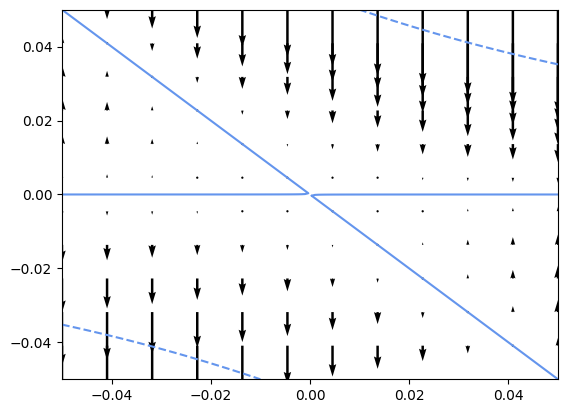

In [35]:
elim = [-0.05,0.05]
vlim = [-0.05,0.05]

ec = np.linspace(elim[0],elim[1],150)
vc = np.linspace(vlim[0],vlim[1],150)

eq = np.linspace(elim[0],elim[1],12)
vq = np.linspace(vlim[0],vlim[1],12)

eC, vC = np.meshgrid(ec,vc)
eQ, vQ = np.meshgrid(eq,vq)

plt.contour(eC,vC,dv_func(eC,vC),levels=1,colors='cornflowerblue')
# plt.colorbar()
plt.quiver(eQ,vQ,de(eQ,vQ),dv_func(eQ,vQ))

plt.ylabel(r'$v$',fontsize=fntsize[1])
plt.xlabel(r'$\epsilon$',fontsize=fntsize[1])
plt.title(r'$(\dot\epsilon,\dot v)$',fontsize=fntsize[2])

plt.show()

### Center manifold

`.expand()` just *expands* all the multiplication. It is a necessary step, so that **sympy** can collect terms.

`.coeff(x,0)` collects all the *coefficients* in `N` with a `x` power of `0`. Then `.coeff(eps,1)` collects coefficients of that set.

That should fill out all the terms for $h$. `.solve()` finds the solutions for the three above equations.

`.subs()` *substitutes* symbolic variables of an existing equation; below I am filling in `h` with the above solutions `abc`.

Similarly, `v` is subbstituted for `h_sub` in `dx` (again `dx` $=\dot x$)

`.lambdify()` converts a symbolic variable into a numerical function.

## B 

suppose $x,y\in\mathbb{R}$, and
$$\begin{align}\frac{dx}{dt} =&\; \frac{x}{2} + y + x^2y\\
\frac{dy}{dt} =&\; x + 2y + \epsilon y + y^2\end{align}$$

---

### Define system

In [ ]:
x, y, eps, A, B, g1, g2, u, v = smp.symbols(r'x y \epsilon A B g_1 g_2 u v')

dx = x/2 + y + x**2*y
dx

In [ ]:
dy = x + 2*y + eps*y + y**2
dy

### Jacobian

The 

In [ ]:
Jac = smp.Matrix([[smp.diff(dx,x),smp.diff(dx,y)],
                  [smp.diff(dy,x),smp.diff(dy,y)]])

Jac

In [ ]:
J0 = Jac.subs([[x,0],[y,0]])
J0.subs(eps,0)

In [ ]:
J0 = J0.subs(eps,0)
smp.Matrix.eigenvals(J0)

In [ ]:
J0 = J0.subs(eps,0)
v1 = smp.Matrix.eigenvects(J0)[0][2][0]
v1

In [ ]:
v2 = smp.Matrix.eigenvects(J0)[1][2][0]
v2

### Transform 

In [ ]:
w, u = smp.symbols('w u')
wu = smp.Matrix([w,u])
xy = smp.Matrix([x,y])

In [ ]:
P = smp.Matrix([[-2,1],[1/2,1]]).T
Pinv = P.inv()

In [ ]:
trans = P@wu
trans

In [ ]:
dwu = (Pinv@smp.Matrix([dx,dy]))
dwu

In [ ]:
dwu = dwu.subs([[x,trans[0]],[y,trans[1]]])
dw = dwu[0].expand()
du = dwu[1].expand()

In [ ]:
dw

In [ ]:
dw.coeff(w,1).coeff(u,0).coeff(eps,0)

In [ ]:
du.coeff(w,0).coeff(u,1).coeff(eps,0)

In [ ]:
A = dw.coeff(w,1).coeff(u,0).coeff(eps,0)
B = du.coeff(w,0).coeff(u,1).coeff(eps,0)

g1 = dw - A*w
g2 = du - B*u

In [ ]:
N

In [ ]:
h =  a*w**2 + b*w*eps + c*eps**2
dh = smp.diff(h,w)
N = (dh*(A*w + g1)-B*h - g2).subs(u,h)
N

In [ ]:
N = N.expand()

In [ ]:
N.coeff(w,0).coeff(eps,1)

In [ ]:
N.coeff(w,1).coeff(eps,0)

In [ ]:
w_eps = N.coeff(w,1).coeff(eps,1)
w_eps

In [ ]:
w_pow2 = N.coeff(w,2).coeff(eps,0)
w_pow2

In [ ]:
eps_pow2 = N.coeff(w,0).coeff(eps,2)
eps_pow2

In [ ]:
abc = smp.solve([w_pow2,w_eps,eps_pow2],[a,b,c])
abc

In [ ]:
h_sub = h.subs([[a,abc[a]],[b,abc[b]],[c,abc[c]]])
h_sub

In [ ]:
dw_sub = dw.subs(u,h_sub)
dw_sub

In [ ]:
dw_func = smp.lambdify([eps,w],dw_sub)
h_func = smp.lambdify([eps,w],h_sub)

In [ ]:
def de(e,w):
    return 0

In [ ]:
fntsize = [10,12,14]

In [ ]:
elim = [-0.04,0.2]
wlim = [-0.1,0.2]

ec = np.linspace(elim[0],elim[1],150)
wc = np.linspace(wlim[0],wlim[1],150)

eq = np.linspace(elim[0],elim[1],12)
wq = np.linspace(wlim[0],wlim[1],12)

eC, wC = np.meshgrid(ec,wc)
eQ, wQ = np.meshgrid(eq,wq)

plt.contour(eC,wC,dw_func(eC,wC),levels=1,colors='cornflowerblue')
# plt.colorbar()
plt.quiver(eQ,wQ,de(eQ,wQ),dw_func(eQ,wQ))

plt.ylabel(r'$w$',fontsize=fntsize[1])
plt.xlabel(r'$\epsilon$',fontsize=fntsize[1])
plt.title(r'$(\dot\epsilon,\dot w)$',fontsize=fntsize[2])

plt.show()

### $\mathcal{N}$

Since $\dot y$ is the function that is dependent on the bifurcation parameter, $\epsilon$, $y$ will be the variable to build the equation $h(y,\epsilon)$.

$$\begin{align}\dot y =& 2y + (\epsilon y + x + y^2) \\
\dot x =& \frac{1}{2}x + (x^2y + y) \end{align}\begin{cases}A = 2\\
g_1 = \epsilon y + x + y^2\\
B = \frac{1}{2}\\
g_2 = (x^2y + y)\end{cases}$$

Which all is plugged into the equation

$$\mathcal{N} = 0 = Dh(Ay + g_1) -Bh - g_2$$

Now $h(y,\epsilon)$ needs to be designed. It is helpfult to select $h(y,\epsilon)$ so it simplifies the coefficient matching when solving $\mathcal{N}$. Observe the terms in $g_1$ and $g_2$ with powers of $y$ and $\epsilon$: $y\epsilon$, $y^2$, and $y$. So $h(y,\epsilon)$ is selected as

$$h = a y + b y^2 + c y\epsilon$$

where $a,b,c$ are the parameters solved for to make $\mathcal{N}=0$. Which is done with the following symbolic solver

`.expand()` just *expands* all the multiplication. It is a necessary step, so that **sympy** can collect terms.

`.coeff(eps,0)` collects all the *coefficients* in `N` with a `eps` power of `0`. Then `.coeff(y,1)` collects coefficients of that set.

That should fill out all the terms for $h$. `.solve()` finds the solutions for the three above equations.

Two sets of $a,b,c$ were found. I wonder if one can be selected by looking at more terms of $\mathcal{N}$, but I am interested to see the difference in results. From my understanding of class discussions, it shouldn't matter which is selected.

`.subs()` *substitutes* symbolic variables of an existing equation; below I am filling in `h` with the above solutions `abc`.

Similarly, `x` is subbstituted for `h_sub` in `dy` (again `dy` $=\dot y$)

### Sim

`.lambdify()` converts a symbolic variable into a numerical function.

# Problem 2

Compute the normal form for a map in the neighborhood of a fixed point having the linear part 

$$\begin{pmatrix}1&1\\0&1\end{pmatrix}$$

through second order terms. **Compare** your results to Ex 19.1.2, which has linear part.

$$\begin{pmatrix}0&1\\0&0\end{pmatrix}$$


---

$$L_J^k(h_k(y)) \equiv -(Dh_k(y)Jy-Jh_k(y))$$

In [ ]:
x, y, J = smp.symbols('x y J')

h1 = smp.Matrix([[x**2],
                 [0]])
h2 = smp.Matrix([[x*y],
                 [0]])
h3 = smp.Matrix([[y**2],
                 [0]])
h4 = smp.Matrix([[0],
                 [x**2]])
h5 = smp.Matrix([[0],
                 [x*y]])
h6 = smp.Matrix([[0],
                 [y**2]])

H = [h1,h2,h3,h4,h5,h6]

J = smp.Matrix([[1,1],
                [0,1]])

v = smp.Matrix([[0],
                [y]])

In [ ]:
h = H[0]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L1 = J@h - Dh@J@v
# L1

In [ ]:
h = H[1]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L2 = J@h - Dh@J@v
# L2

In [ ]:
h = H[2]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L3 = J@h - Dh@J@v
# L3

In [ ]:
h = H[3]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L4 = J@h - Dh@J@v
# L4

In [ ]:
h = H[4]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L5 = J@h - Dh@J@v
# L5.expand()

In [ ]:
h = H[5]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L6 = J@h - Dh@J@v
# L6

In [ ]:
L1

In [ ]:
L2

In [ ]:
L3

In [ ]:
L4

In [ ]:
L5

In [ ]:
L6

In [ ]:
G = smp.Matrix([[1,-2,0,0,0,0],
               [0,0,-1,0,0,0],
               [0,0,-1,0,0,0],
               [1,0,0,1,-2,0],
               [0,1,0,0,0,-1],
               [0,0,1,0,0,-1]]).T
G

In [ ]:
smp.Matrix.left_eigenvects(G)[1]

In [ ]:
J@v

$$\begin{align}\dot x =&\; y + 0 +\mathcal{O}(3)\\
\dot y =&\; y + a_1x^2 + a_2xy +\mathcal{O}(3) \end{align}$$ 

## EX 19.1.2

In [ ]:
x, y, J = smp.symbols('x y J')

h1 = smp.Matrix([[x**2],
                 [0]])
h2 = smp.Matrix([[x*y],
                 [0]])
h3 = smp.Matrix([[y**2],
                 [0]])
h4 = smp.Matrix([[0],
                 [x**2]])
h5 = smp.Matrix([[0],
                 [x*y]])
h6 = smp.Matrix([[0],
                 [y**2]])

H = [h1,h2,h3,h4,h5,h6]

J = smp.Matrix([[0,1],
                [0,0]])

v = smp.Matrix([[0],
                [y]])

In [ ]:
h = H[0]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L1 = J@h - Dh@J@v

h = H[1]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L2 = J@h - Dh@J@v

h = H[2]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L3 = J@h - Dh@J@v

h = H[3]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L4 = J@h - Dh@J@v

h = H[4]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L5 = J@h - Dh@J@v

h = H[5]
Dh = smp.Matrix([[smp.diff(h[0],x),smp.diff(h[0],y)],
                 [smp.diff(h[1],x),smp.diff(h[1],y)]])

L6 = J@h - Dh@J@v

In [ ]:
L1

In [ ]:
L2

In [ ]:
L3

In [ ]:
L4

In [ ]:
L5

In [ ]:
L6

In [ ]:
G_ex = smp.Matrix([[0,-2,0,0,0,0],
               [0,0,-1,0,0,0],
               [0,0,0,0,0,0],
               [1,0,0,0,-2,0],
               [0,1,0,0,0,-1],
               [0,0,1,0,0,0]]).T
G_ex

In [ ]:
smp.Matrix.left_eigenvects(G_ex)

In [ ]:
smp.Matrix.left_eigenvects(G_ex)[0][2][1].T

In [ ]:
smp.Matrix.left_eigenvects(G_ex)[0][2][0].T

$$\begin{align}\dot x =&\; y + a_1x^2 +\mathcal{O}(3)\\
\dot y =&\; 0 + a_2xy + a_3x^2 +\mathcal{O}(3) \end{align}$$ 